In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import efficient_su2, UCRYGate

from scipy.optimize import minimize
import matplotlib.pyplot as plt


In [2]:
def ansatz_circuit(n_qubits, depth, angles):
    su2 = efficient_su2(n_qubits, su2_gates = ["ry"], entanglement = "circular", reps = depth)
    return su2.assign_parameters(angles)

def num_ansatz_param(n_qubits, depth):
    su2 = efficient_su2(n_qubits, su2_gates = ["ry"], entanglement = "circular", reps = depth)
    return su2.num_parameters

def ansatz_state(n_qubits, depth, angles):
    return Statevector.from_instruction(ansatz_circuit(n_qubits, depth, angles)).data.real

def fit_vector(target_f, n_qubits, depth, n_restarts, tol, seed):
    n_params = num_ansatz_param(n_qubits, depth)
    def obj(params):
        lam0        = params[0]
        angles      = params[1:]
        v_hat       = ansatz_state(n_qubits, depth, angles)
        candidate   = lam0 * v_hat
        return np.linalg.norm(target_f - candidate)
    rng  = np.random.default_rng(seed)
    best = None
    for trial in range(n_restarts):
        x0 = np.concatenate([
            [np.linalg.norm(target_f) * (0.5+ rng.random())],
            rng.uniform(0, 2*np.pi, size = n_params)
            ])
        res = minimize(obj, x0, method = "BFGS")
        if best is None or res.fun < best.fun:
            best = res
    success = best.fun <= tol
    return best, success

def build_inner_product(v_theta, v_lambda):
    n_qubits = v_theta.num_qubits
    ancilla  = QuantumRegister(1, name = "H anc") 
    reg      = QuantumRegister(n_qubits, name = "reg")
    cbit     = ClassicalRegister(1, name = "meas")
    qc       = QuantumCircuit(ancilla, reg, cbit)

    qc.h(ancilla[0])
    ctrl_v_theta   = v_theta.to_gate().control(1)
    qc.append(ctrl_v_theta, [ancilla[0]] + list(reg))
    v_lambda_dag   = v_lambda.inverse()
    ctrl_v_lam_dag = v_lambda_dag.to_gate().control(1)
    qc.append(ctrl_v_lam_dag, [ancilla[0]] + list(reg))
    qc.h(ancilla[0])
    qc.measure(ancilla[0], cbit[0])
    return qc

def diagonal_operator_core(qc, ancilla, reg1, q_regs, v_p, v_qs):
    qc.append(v_p.to_gate(), list(reg1))
    for k, vq in enumerate(v_qs):
        ctrl_vq = vq.to_gate().control(1)
        qc.append(ctrl_vq, [ancilla[0]] + list(q_regs[k]))
        for i in range(len(reg1)):
            qc.ccx(ancilla[0], reg1[i], q_regs[k][i])
def build_diagonal_operator_general(v_p, v_qs : list[QuantumCircuit]):
    n_qubits = v_p.num_qubits
    for vq in v_qs:
        assert vq.num_qubits == n_qubits

    Nt = len(v_qs)
    ancilla = QuantumRegister(1, name = "H anc")
    reg1    = QuantumRegister(n_qubits, name = "reg1")
    q_regs  = [QuantumRegister(n_qubits, name = f"reg{k+2}") for k in range(Nt)]
    cbit    = ClassicalRegister(1, name = "meas")
    qc      = QuantumCircuit(ancilla, reg1, *q_regs, cbit)
    qc.h(ancilla[0])
    diagonal_operator_core(qc, ancilla, reg1, q_regs, v_p, v_qs)
    qc.h(ancilla[0])
    qc.measure(ancilla[0], cbit[0])
    return qc

def build_diagonal_operator(v_lambda, v_theta):
    return build_diagonal_operator_general(v_lambda, [v_theta])

def run_hadamard_test(qc):
    qc_no_measure = qc.remove_final_measurements(inplace = False)
    sv            = Statevector.from_instruction(qc_no_measure)
    probs         = sv.probabilities_dict(qargs=[0])
    return probs.get('0', 0.0) - probs.get('1', 0.0)

def shifted_v_circuit(v_p, dagger : bool = False):
    n_qubits = v_p.num_qubits
    qc= QuantumCircuit(n_qubits)
    qc.append(v_p.to_gate(), range(n_qubits))
    increment = QuantumCircuit(n_qubits)
    for i in range(n_qubits-1, 0, -1):
        increment.mcx(list(range(i)), i)
    increment.x(0)

    shift = increment if dagger else increment.inverse()
    qc.append(shift.to_gate(), range(n_qubits))
    return qc

def diagonal_scaled_state(v_p, m_hat : np.ndarray):
    n_qubits = v_p.num_qubits
    m_max    = np.max(np.abs(m_hat))
    qc       = QuantumCircuit(n_qubits + 1)
    qc.append(v_p.to_gate(), range(n_qubits))
    angles   = [2*np.arcsin(np.clip(m_hat[i]/m_max, -1, 1)) for i in range(2**n_qubits)]
    qc.append(UCRYGate(angles), [n_qubits] + list(range(n_qubits)))
    sv       = Statevector.from_instruction(qc)
    N        = 2**n_qubits
    p_unnorm = sv.data[N : 2*N]
    return p_unnorm, m_max

def build_overlap_operator(v_a, v_b, v_qs):
    n   = v_a.num_qubits
    anc = QuantumRegister(1, name = "H anc")
    reg1   = QuantumRegister(n, name="reg1")
    q_regs = [QuantumRegister(n, name=f"reg{k+2}") for k in range(len(v_qs))]
    cbit   = ClassicalRegister(1, name="meas")
    qc     = QuantumCircuit(anc, reg1, *q_regs, cbit)

    qc.h(anc[0])
    qc.x(anc[0])
    qc.append(v_a.to_gate().control(1), [anc[0]] + list(reg1))   # anc = 0
    qc.x(anc[0])
    qc.append(v_b.to_gate().control(1), [anc[0]] + list(reg1))   # anc = 1
    for k, vq in enumerate(v_qs):
        qc.append(vq.to_gate().control(1), [anc[0]] + list(q_regs[k]))
        for i in range(n):
            qc.ccx(anc[0], reg1[i], q_regs[k][i])                # XOR trick
    qc.h(anc[0])
    qc.measure(anc[0], cbit[0])
    return qc



def B_func(Kappa, X):
    return Kappa * X

def b_vec(n_qubits, x, kappa):
    alpha_gauss = (np.sqrt(3) + 1) / (2 * np.sqrt(3))
    Nq = 2**n_qubits
    b = np.zeros(Nq + 1)

    for e in range(Nq):
        X0, X1 = x[e], x[e+1]
        he = X1 - X0
        for g, (Ng0, Ng1) in enumerate([(alpha_gauss, 1-alpha_gauss), (1-alpha_gauss, alpha_gauss)]):
            Xg = Ng0*X0 + Ng1*X1
            weight = (he/2) * B_func(kappa, Xg)
            b[e]   += weight * Ng0
            b[e+1] += weight * Ng1
    return b

In [3]:
def E2_T1(v_circ, m1_circ, lam0_v, lam0_m1, ubar, h0):
    qc      = build_inner_product(m1_circ, v_circ)
    result  = run_hadamard_test(qc)
    return -2*ubar/h0 * lam0_v * lam0_m1 * result

def E2_T2(v_circ, m2_circ, lam0_v, lam0_m2):
    qc      = build_diagonal_operator(v_circ, m2_circ)
    result  = run_hadamard_test(qc)
    return lam0_v**2 * lam0_m2 * result

def E2_T3(v_circ, m3_hat, lam0_v):
    qc      = shifted_v_circuit(v_circ)
    q_state = Statevector.from_instruction(qc).data.real
    p_unnorm , m3_max = diagonal_scaled_state(v_circ, m3_hat)
    inner   = np.real(np.vdot(p_unnorm, q_state)) * m3_max
    return 2 * lam0_v**2 * inner



def NBC(v_circ, m1_1_circ, P_bar, lam0_v, lam0_m1_1):
    qc      = build_inner_product( m1_1_circ, v_circ)
    result  = run_hadamard_test(qc)
    return -lam0_v * lam0_m1_1 * P_bar * result

def E_B(v_circ, b_circ, lam0_v, lam_b, ubar, b0 = 0.0):
    qc     = build_inner_product(v_circ, b_circ)
    result = run_hadamard_test(qc)
    return -(b0 * ubar + lam0_v * lam_b * result)

In [4]:
n_qubits = 3
depth    = 2
L        = 1.0
u_left   = 0.0
u_right  = 0.0
P_bar    = 0.0
mu       = 1.0
N_q      = 2**n_qubits
x        = np.linspace(0, L, N_q + 1)
kappa    = 1.5

he = np.zeros(N_q)
for i in range(N_q):
    he[i] = x[i+1] - x[i]

b_vec = b_vec(n_qubits, x, kappa)

In [5]:
m_1 = np.zeros(N_q)
m_2 = np.zeros(N_q)
m_3 = np.zeros(N_q)
m_4 = np.zeros(N_q)
m_5 = np.zeros(N_q)
m_6 = np.zeros(N_q)
m_7 = np.zeros(N_q)
m_8 = np.zeros(N_q)
m_9 = np.zeros(N_q)
m_10 = np.zeros(N_q)
m_11 = np.zeros(N_q)
m_12 = np.zeros(N_q)
m_13 = np.zeros(N_q)
m_14 = np.zeros(N_q)
m_15 = np.zeros(N_q)
m_1_1 = np.zeros(N_q)
m_1[0] = 1.0
m_1_1[-1] = 1.0

for i in range(N_q):
    if i == N_q-1:
        m_2[i]  = 1/he[i]
        m_3[i]  = 0
        m_4[i]  = (1/he[i])**2
        m_5[i]  = 0
        m_8[i]  = 0
        m_10[i] = (1/he[i])**3
        m_11[i] = (1/he[i])**4
        m_12[i] = 0
        m_14[i] = 0
    else:
        m_2[i]  = (1/he[i]) + (1/he[i+1])
        m_3[i]  = 1/he[i+1]
        m_4[i]  = (1/he[i])**2 - (1/he[i+1])**2
        m_5[i]  = (1/he[i+1])**2
        m_8[i]  = (1/he[i+1])**3
        m_10[i] = (1/he[i])**3 + (1/he[i+1])**3
        m_11[i] = (1/he[i])**4 - (1/he[i+1])**4
        m_12[i]  = (1/he[i+1])**4
        m_14[i]  = (1/he[i+1])**4

for i in range(N_q):
    if i == 0:
        m_6[i]  = 0
        m_7[i]  = 0
        m_9[i]  = 0
        m_13[i] = 0
        m_15[i] = 0
    else:
        m_6[i]  = (1/he[i])**2
        m_7[i]  = (1/he[i])**3
        m_9[i]  = (1/he[i])**3
        m_13[i] = (1/he[i])**4
        m_15[i] = (1/he[i])**4

m1_vector,  ok1     = fit_vector(m_1, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 1)
m2_vector,  ok2     = fit_vector(m_2, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 2)
m3_vector,  ok3     = fit_vector(m_3, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 3)
m4_vector,  ok4     = fit_vector(m_4, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 4)
m5_vector,  ok5     = fit_vector(m_5, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 5)
m6_vector,  ok6     = fit_vector(m_6, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 6)
m1_1_vector, ok1_1  = fit_vector(m_1_1, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 7)
b_vector,   okb     = fit_vector(b_vec[1:], n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 8 )
m7_vector,  ok7     = fit_vector(m_7, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 9)
m8_vector,  ok8     = fit_vector(m_8, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 10)
m9_vector,  ok9     = fit_vector(m_9, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 11)
m10_vector, ok10    = fit_vector(m_10, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 12)
m11_vector, ok11    = fit_vector(m_11, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 13)
m12_vector, ok12    = fit_vector(m_12, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 14)
m13_vector, ok13    = fit_vector(m_13, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 15)
m14_vector, ok14    = fit_vector(m_14, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 16)
m15_vector, ok15    = fit_vector(m_15, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 17)



m1_circ   = ansatz_circuit(n_qubits, depth, angles=m1_vector.x[1:])
m2_circ   = ansatz_circuit(n_qubits, depth, angles=m2_vector.x[1:])
m3_circ   = ansatz_circuit(n_qubits, depth, angles=m3_vector.x[1:])
m4_circ   = ansatz_circuit(n_qubits, depth, angles=m4_vector.x[1:])
m5_circ   = ansatz_circuit(n_qubits, depth, angles=m5_vector.x[1:])
m6_circ   = ansatz_circuit(n_qubits, depth, angles=m6_vector.x[1:])
m1_1_circ = ansatz_circuit(n_qubits, depth, angles=m1_1_vector.x[1:])
b_circ    = ansatz_circuit(n_qubits, depth, angles=b_vector.x[1:])
m7_circ   = ansatz_circuit(n_qubits, depth, angles=m7_vector.x[1:])
m8_circ   = ansatz_circuit(n_qubits, depth, angles=m8_vector.x[1:])
m9_circ   = ansatz_circuit(n_qubits, depth, angles=m9_vector.x[1:])
m10_circ  = ansatz_circuit(n_qubits, depth, angles=m10_vector.x[1:])
m11_circ  = ansatz_circuit(n_qubits, depth, angles=m11_vector.x[1:])
m12_circ  = ansatz_circuit(n_qubits, depth, angles=m12_vector.x[1:])
m13_circ  = ansatz_circuit(n_qubits, depth, angles=m13_vector.x[1:])
m14_circ  = ansatz_circuit(n_qubits, depth, angles=m14_vector.x[1:])
m15_circ  = ansatz_circuit(n_qubits, depth, angles=m15_vector.x[1:])


lam0_m1   = m1_vector.x[0]
lam0_m2   = m2_vector.x[0]
lam0_m3   = m3_vector.x[0]
lam0_m4   = m4_vector.x[0]
lam0_m5   = m5_vector.x[0]
lam0_m6   = m6_vector.x[0]
lam0_m1_1 = m1_1_vector.x[0]
lam_b     = b_vector.x[0]
lam0_m7   = m7_vector.x[0]
lam0_m8   = m8_vector.x[0]
lam0_m9   = m9_vector.x[0]
lam0_m10  = m10_vector.x[0]
lam0_m11  = m11_vector.x[0]
lam0_m12  = m12_vector.x[0]
lam0_m13  = m13_vector.x[0]
lam0_m14  = m14_vector.x[0]
lam0_m15  = m15_vector.x[0]


In [6]:
n_qubits = 3
N_q      = 2**n_qubits
L        = 1.0
u_left   = 0.0
P_bar    = 0.0
mu       = 1.0
kappa    = 1.5
x        = np.linspace(0, L, N_q + 1)
he       = np.diff(x)
P        = 10**2

def classical_b_vec(n_qubits, x, kappa):
    alpha_gauss = (np.sqrt(3) + 1) / (2 * np.sqrt(3))
    b = np.zeros(N_q + 1)
    for e in range(N_q):
        X0, X1 = x[e], x[e+1]
        h = X1 - X0
        for g, (Ng0, Ng1) in enumerate([(alpha_gauss, 1-alpha_gauss), (1-alpha_gauss, alpha_gauss)]):
            Xg = Ng0*X0 + Ng1*X1
            weight = (h/2) * (kappa * Xg)
            b[e]   += weight * Ng0
            b[e+1] += weight * Ng1
    return b

b_full = classical_b_vec(n_qubits, x, kappa)
b_active = b_full[1:] # Excluding the known left boundary


def classical_energy(v):

    u = np.concatenate(([u_left], v))
    
    E2 = 0.0
    E3 = 0.0
    E4 = 0.0
    E5 = 0.0
    E6 = 0.0
    E7 = 0.0
    E8 = 0.0
    E9 = 0.0
    for i in range(N_q):
        du = u[i+1] - u[i]
        E2 += (du**2) / he[i]
        E3 += (du**3) / (he[i]**2)
        E4 += (du**4) / (he[i]**3)
        E5 += (du**5) / (he[i]**4)
        E6 += (du**6) / (he[i]**5)
        E7 += (du**7) / (he[i]**6)
        E8 += (du**8) / (he[i]**7)
        E9 += (du**9) / (he[i]**8)
        
    E2 = mu * E2
    E3 = -(mu / 3.0) * E3
    E4 = (mu / 4.0) * E4
    E5 = -(mu / 5.0) * E5
    E6 = (mu / 6.0) * E6
    E7 = -(mu / 7.0) * E7
    E8 = (mu / 8.0) * E8
    E9 = -(mu / 9.0) * E9
        
    # B_term calculates the pure external work (positive)
    B_term = np.dot(v, b_active) 
    
    # NBC_term already has the negative sign built in
    NBC_term = -P_bar * v[-1] 
    
    # FIX: Subtract the body force work from the internal energy
    return E2 + E3 + E4 + E5 + E6 + E7 + E8 + E9 - B_term + NBC_term


res_classical = minimize(classical_energy, np.zeros(N_q), method="BFGS", options={'gtol': 1e-8})


In [7]:
def IHT_T1(v_circ, n1_circ, lam0_v, lam0_n1 , ubar):
    qc     = build_inner_product(v_circ, n1_circ)
    result = run_hadamard_test(qc)
    return lam0_v * lam0_n1 * result - ubar

def IHT_T2(y_circ, n2_circ, lam0_y, lam0_n2):
    qc     = build_inner_product(y_circ, n2_circ)
    result = run_hadamard_test(qc)
    return -2 * lam0_y * lam0_n2 * result

def IHT_T3(y_circ, y_angles, n3_circ, lam0_y, lam0_n3, n_qubits, depth):
    y_copy_1 = ansatz_circuit(n_qubits, depth, y_angles)
    qc       = build_diagonal_operator_general(y_circ, [y_copy_1, n3_circ])
    result   = run_hadamard_test(qc)
    return -(2/3)*lam0_y**3 * lam0_n3 * result

def IHT_T4(y_circ, n4_circ, lam0_y, lam0_n4, P):
    qc       = build_diagonal_operator(y_circ, n4_circ)
    result   = run_hadamard_test(qc)
    return 2 * P * lam0_y**2 * lam0_n4 * result

def IHT_T5(v_circ, y_circ, n5_circ, n6_circ, lam0_v, lam0_y, lam0_n5, lam0_n6, ubar, h0, P):
    qc1     = build_inner_product(v_circ, n5_circ)
    result1 = run_hadamard_test(qc1)
    qc2     = build_inner_product(y_circ, n6_circ)
    result2 = run_hadamard_test(qc2)
    return ((P/2)*(ubar ** 2 - 2 * ubar * lam0_v * lam0_n5 * result1 + lam0_v**2 * lam0_n5**2 * result1**2)*(lam0_y**2 * lam0_n6**2 * result2**2))/h0

def IHT_T6(v_circ, y_circ, v_angles, y_angles, n7_circ, n8_circ, n9_circ, lam0_v, lam0_y, lam0_n7, lam0_n8, lam0_n9, n_qubits, depth, P):
    y_copy_1 = ansatz_circuit(n_qubits, depth, y_angles)
    y_copy_2 = ansatz_circuit(n_qubits ,depth, y_angles)
    y_copy_3 = ansatz_circuit(n_qubits, depth, y_angles)
    y_copy_4 = ansatz_circuit(n_qubits ,depth, y_angles)
    v_copy_1 = ansatz_circuit(n_qubits, depth, v_angles)
    v_copy_2 = ansatz_circuit(n_qubits ,depth, v_angles)
    v_copy_3 = ansatz_circuit(n_qubits ,depth, v_angles)
    qc1      = build_diagonal_operator_general(v_circ, [y_circ, y_copy_1, n7_circ])
    result1  = run_hadamard_test(qc1)
    qc2      = build_diagonal_operator_general(shifted_v_circuit(v_copy_1, dagger=True), [y_copy_2, y_copy_2, n8_circ])
    result2  = run_hadamard_test(qc2)
    qc3      = build_diagonal_operator_general(y_copy_4, [v_copy_2, shifted_v_circuit(v_copy_3, dagger=True), n9_circ])
    result3  = run_hadamard_test(qc3)
    return (P/2) * lam0_v**2 * lam0_y **2 * (lam0_n7 * result1 + lam0_n8 * result2 - 2 * lam0_n9 * result3)

def IHT_T7(v_circ, y_circ, n10_circ, n11_circ, lam0_v, lam0_y, lam0_n10, lam0_n11, ubar, h0, P):
    qc1      = build_inner_product(v_circ, n10_circ)
    result1  = run_hadamard_test(qc1)
    qc2      = build_inner_product(y_circ, n11_circ)
    result2  = run_hadamard_test(qc2)
    return  ((-P)*(ubar ** 2 - 2 * ubar * lam0_v * lam0_n10 * result1 + lam0_v**2 * lam0_n10**2 * result1**2)*(lam0_y * lam0_n11 * result2))/h0

def IHT_T8(v_circ, y_circ, v_angles, y_angles, n12_circ, n13_circ, n14_circ, lam0_v, lam0_y, lam0_n12, lam0_n13, lam0_n14, n_qubits, depth, P):
    y_copy_1 = ansatz_circuit(n_qubits, depth, y_angles)
    y_copy_2 = ansatz_circuit(n_qubits ,depth, y_angles)
    v_copy_1 = ansatz_circuit(n_qubits, depth, v_angles)
    v_copy_2 = ansatz_circuit(n_qubits ,depth, v_angles)
    v_copy_3 = ansatz_circuit(n_qubits ,depth, v_angles)
    qc1      = build_diagonal_operator_general(v_circ, [y_circ, n12_circ])
    result1  = run_hadamard_test(qc1)
    qc2      = build_diagonal_operator_general(shifted_v_circuit(v_copy_1, dagger=True), [y_copy_1, n13_circ])
    result2  = run_hadamard_test(qc2)
    qc3      = build_overlap_operator(v_circ, shifted_v_circuit(v_copy_1, dagger=True), [y_circ, n14_circ])
    result3  = run_hadamard_test(qc3)
    return (-P) * lam0_v**2 * lam0_y * (lam0_n12 * result1 + lam0_n13 * result2 - 2 * lam0_n14 * result3)

def IHT_T9(v_circ, y_circ, v_angles, y_angles, n15_circ, n16_circ, lam0_v, lam0_y, lam0_n15, lam0_n16, n_qubits, depth, ubar, P):
    y_copy_1 = ansatz_circuit(n_qubits, depth, y_angles)
    y_copy_2 = ansatz_circuit(n_qubits, depth, y_angles)
    v_copy_1 = ansatz_circuit(n_qubits, depth, v_angles)
    qc1      = build_inner_product(y_circ, n15_circ)
    result1  = run_hadamard_test(qc1)
    qc2      = build_diagonal_operator(y_copy_1, v_circ)
    result2  = run_hadamard_test(qc2)
    qc3      = build_diagonal_operator_general(y_copy_2, [shifted_v_circuit(v_copy_1, dagger=True), n16_circ])
    result3  = run_hadamard_test(qc3)
    return -2 * P * (ubar * lam0_y**2 * lam0_n15 **2 * result1**2 - lam0_v * lam0_y **2 * result2 + lam0_v * lam0_y**2 * lam0_n16 * result3)

def IHT_T10(v_circ, y_circ, v_angles, y_angles, n17_circ, n18_circ, lam0_v, lam0_y, lam0_n17, lam0_n18, n_quibts, depth, ubar, P):
    y_copy_1 = ansatz_circuit(n_qubits, depth, y_angles)
    y_copy_2 = ansatz_circuit(n_qubits, depth, y_angles)
    qc1      = build_inner_product(y_circ, n17_circ)
    result1  = run_hadamard_test(qc1)
    qc2      = build_inner_product(y_circ, v_circ)
    result2  = run_hadamard_test(qc2)
    qc3      = build_overlap_operator(shifted_v_circuit(v_circ, dagger = True), y_circ, [n18_circ])
    result3  = run_hadamard_test(qc3)
    return 2 * P * (ubar * lam0_y * lam0_n17 * result1 - lam0_y * lam0_v * result2 + lam0_y * lam0_v * lam0_n18 * result3)

In [8]:
n1 = np.array([0.0] * (N_q - 1) + [1.0])
n2 = np.array([he[i] for i in range(N_q)])
n3 = np.array([he[i] for i in range(N_q)])
n4 = np.array([he[i] for i in range(N_q)])
n5 = np.array([1.0] + [0.0] * (N_q - 1))
n6 = np.array([1.0] + [0.0] * (N_q - 1))
n7 = np.array([0.0] + [1/he[i] for i in range(1, N_q)])
n8 = np.array([0.0] + [1/he[i] for i in range(1, N_q)])
n9 = np.array([0.0] + [1/he[i] for i in range(1, N_q)])
n10 = np.array([1.0] + [0.0] * (N_q - 1))
n11 = np.array([1.0] + [0.0] * (N_q - 1))
n12 = np.array([0.0] + [1/he[i] for i in range(1, N_q)])
n13 = np.array([0.0] + [1/he[i] for i in range(1, N_q)])
n14 = np.array([0.0] + [1/he[i] for i in range(1, N_q)])
n15 = np.array([1.0] + [0.0] * (N_q - 1))
n16 = np.array([0.0] + [1.0] * (N_q - 1))
n17 = np.array([1.0] + [0.0] * (N_q - 1))
n18 = np.array([0.0] + [1.0] * (N_q - 1))

n1_vec,  okk1   = fit_vector(n1,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 1)
n2_vec,  okk2   = fit_vector(n2,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 2)
n3_vec,  okk3   = fit_vector(n3,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 3)
n4_vec,  okk4   = fit_vector(n4,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 4)
n5_vec,  okk5   = fit_vector(n5,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 5)
n6_vec,  okk6   = fit_vector(n6,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 6)
n7_vec,  okk7   = fit_vector(n7,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 7)
n8_vec,  okk8   = fit_vector(n8,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 8)
n9_vec,  okk9   = fit_vector(n9,  n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 9)
n10_vec, okk10  = fit_vector(n10, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 10)
n11_vec, okk11  = fit_vector(n11, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 11)
n12_vec, okk12  = fit_vector(n12, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 12)
n13_vec, okk13  = fit_vector(n13, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 13)
n14_vec, okk14  = fit_vector(n14, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 14)
n15_vec, okk15  = fit_vector(n15, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 15)
n16_vec, okk16  = fit_vector(n16, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 16)
n17_vec, okk17  = fit_vector(n17, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 17)
n18_vec, okk18  = fit_vector(n18, n_qubits = n_qubits, depth = depth, n_restarts = 6, tol = 1.e-5, seed = 18)


In [9]:
n1_circ = ansatz_circuit(n_qubits, depth, angles = n1_vec.x[1:])
n2_circ = ansatz_circuit(n_qubits, depth, angles = n2_vec.x[1:])
n3_circ = ansatz_circuit(n_qubits, depth, angles = n3_vec.x[1:])
n4_circ = ansatz_circuit(n_qubits, depth, angles = n4_vec.x[1:])
n5_circ = ansatz_circuit(n_qubits, depth, angles = n5_vec.x[1:])
n6_circ = ansatz_circuit(n_qubits, depth, angles = n6_vec.x[1:])
n7_circ = ansatz_circuit(n_qubits, depth, angles = n7_vec.x[1:])
n8_circ = ansatz_circuit(n_qubits, depth, angles = n8_vec.x[1:])
n9_circ = ansatz_circuit(n_qubits, depth, angles = n9_vec.x[1:])
n10_circ = ansatz_circuit(n_qubits, depth, angles = n10_vec.x[1:])
n11_circ = ansatz_circuit(n_qubits, depth, angles = n11_vec.x[1:])
n12_circ = ansatz_circuit(n_qubits, depth, angles = n12_vec.x[1:])
n13_circ = ansatz_circuit(n_qubits, depth, angles = n13_vec.x[1:])
n14_circ = ansatz_circuit(n_qubits, depth, angles = n14_vec.x[1:])
n15_circ = ansatz_circuit(n_qubits, depth, angles = n15_vec.x[1:])
n16_circ = ansatz_circuit(n_qubits, depth, angles = n16_vec.x[1:])
n17_circ = ansatz_circuit(n_qubits, depth, angles = n17_vec.x[1:])
n18_circ = ansatz_circuit(n_qubits, depth, angles = n18_vec.x[1:])

lam0_n1 = n1_vec.x[0]
lam0_n2 = n2_vec.x[0]
lam0_n3 = n3_vec.x[0]
lam0_n4 = n4_vec.x[0]
lam0_n5 = n5_vec.x[0]
lam0_n6 = n6_vec.x[0]
lam0_n7 = n7_vec.x[0]
lam0_n8 = n8_vec.x[0]
lam0_n9 = n9_vec.x[0]
lam0_n10 = n10_vec.x[0]
lam0_n11 = n11_vec.x[0]
lam0_n12 = n12_vec.x[0]
lam0_n13 = n13_vec.x[0]
lam0_n14 = n14_vec.x[0]
lam0_n15 = n15_vec.x[0]
lam0_n16 = n16_vec.x[0]
lam0_n17 = n17_vec.x[0]
lam0_n18 = n18_vec.x[0]

In [10]:
num_ansatz = num_ansatz_param(n_qubits, depth)
rng = np.random.default_rng(0)
n_v_params = 1 + num_ansatz_param(n_qubits, depth)
n_y_params = 1 + num_ansatz_param(n_qubits, depth)

x1 = np.concatenate([
    [0.3], np.zeros(num_ansatz),
    [0.5], np.zeros(num_ansatz),
])

def objective_iht(params):
    n_v_params = 1 + num_ansatz_param(n_qubits, depth)
    lam0_v = params[0]
    v_angles = params[1:n_v_params]
    lam0_y = params[n_v_params]
    y_angles = params[n_v_params+1:]

    v_circ = ansatz_circuit(n_qubits, depth, v_angles)
    y_circ = ansatz_circuit(n_qubits, depth, y_angles)

    val_IHT_T1 = IHT_T1(v_circ, n1_circ, lam0_v, lam0_n1, u_left)
    val_IHT_T2 = IHT_T2(y_circ, n2_circ, lam0_y, lam0_n2)
    val_IHT_T3 = IHT_T3(y_circ, y_angles, n3_circ, lam0_y, lam0_n3, n_qubits, depth)
    val_IHT_T4 = IHT_T4(y_circ, n4_circ, lam0_y, lam0_n4, P)
    val_IHT_T5 = IHT_T5(v_circ, y_circ, n5_circ, n6_circ, lam0_v, lam0_y, lam0_n5, lam0_n6, u_left, he[0], P)
    val_IHT_T6 = IHT_T6(v_circ, y_circ, v_angles, y_angles, n7_circ, n8_circ, n9_circ, lam0_v, lam0_y, lam0_n7, lam0_n8, lam0_n9, n_qubits, depth, P)
    val_IHT_T7 = IHT_T7(v_circ, y_circ, n10_circ, n11_circ, lam0_v, lam0_y, lam0_n10, lam0_n11, u_left, he[0], P)
    val_IHT_T8 = IHT_T8(v_circ, y_circ, v_angles, y_angles, n12_circ, n13_circ, n14_circ, lam0_v, lam0_y, lam0_n12, lam0_n13, lam0_n14, n_qubits, depth, P)
    val_IHT_T9 = IHT_T9(v_circ, y_circ, v_angles, y_angles, n15_circ, n16_circ, lam0_v, lam0_y, lam0_n15, lam0_n16, n_qubits, depth, u_left, P)
    val_IHT_T10 = IHT_T10(v_circ, y_circ, v_angles, y_angles, n17_circ, n18_circ, lam0_v, lam0_y, lam0_n17, lam0_n18, n_qubits, depth, u_left, P)
    val_NBC     = NBC(v_circ, m1_1_circ, P_bar, lam0_v, lam0_m1_1)
    val_B       = E_B(v_circ, b_circ, lam0_v, lam_b, u_left, b0 = 0)
    val_E2_T1   = E2_T1(v_circ, m1_circ, lam0_v, lam0_m1, u_left, he[0])
    val_E2_T2   = E2_T2(v_circ, m2_circ, lam0_v, lam0_m2)
    val_E2_T3   = E2_T3(v_circ, m_3, lam0_v)
    val_E2      = mu*(u_left**2/he[0] + val_E2_T1 + val_E2_T2 - val_E2_T3)
    val_IHT1    = val_IHT_T1 + (1/2) * val_E2 + val_IHT_T2 + val_IHT_T3
    val_IHT2    = val_IHT_T4 + val_IHT_T5 + val_IHT_T6 + val_IHT_T7 + val_IHT_T8 +  val_IHT_T9 + val_IHT_T10 + (P/2)*val_E2
    return val_IHT1 + val_IHT2 + val_B + val_NBC

res = minimize(objective_iht, x1, method="BFGS", options={'maxiter': 5000, 'gtol': 1e-8})


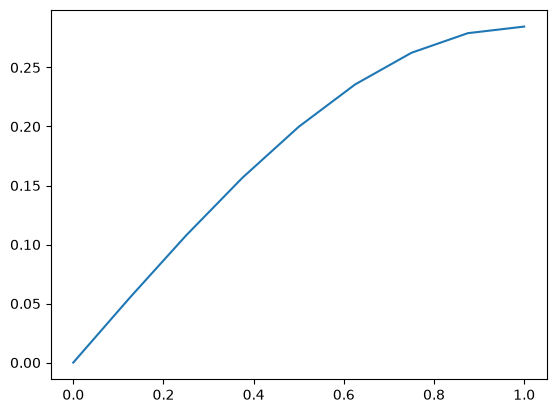

In [11]:
lam0_v_opt = res.x[0]
v_opt    = lam0_v_opt * ansatz_state(n_qubits, depth, res.x[1:n_v_params])
plt.plot(x,np.concatenate(([u_left], v_opt)))
lam0_y_opt = res.x[n_v_params]
y_opt    = lam0_y_opt * ansatz_state(n_qubits, depth, res.x[1+n_v_params:])
